In [1]:
import pandas as pd

file_path = r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Fatality rate\fatality rate_variables_GTD.xlsx"

# Read both sheets
nkill_df = pd.read_excel(file_path, sheet_name="nkill")
nwound_df = pd.read_excel(file_path, sheet_name="nwound")

# Convert nkill
nkill_long = nkill_df.melt(
    id_vars=["Country"], 
    var_name="Year", 
    value_name="nkill"
)

# Convert nwound
nwound_long = nwound_df.melt(
    id_vars=["Country"], 
    var_name="Year", 
    value_name="nwound"
)

panel_df = pd.merge(
    nkill_long,
    nwound_long,
    on=["Country", "Year"],
    how="inner"
)

panel_df["Year"] = panel_df["Year"].astype(int)
panel_df = panel_df.sort_values(by=["Country", "Year"])

# Avoid division by zero
panel_df["fatality_rate"] = panel_df["nkill"] / (panel_df["nkill"] + panel_df["nwound"])

# Handle cases where nkill + nwound = 0
panel_df["fatality_rate"] = panel_df["fatality_rate"].fillna(0)

panel_df

,Country,Year,nkill,nwound,fatality_rate
0,Afghanistan,1970,NaN,NaN,0.000000
204,Afghanistan,1971,NaN,NaN,0.000000
408,Afghanistan,1972,NaN,NaN,0.000000
612,Afghanistan,1973,0.0,1.0,0.000000
816,Afghanistan,1974,NaN,NaN,0.000000
...,...,...,...,...,...
9383,Zimbabwe,2016,NaN,NaN,0.000000
9587,Zimbabwe,2017,0.0,1.0,0.000000
9791,Zimbabwe,2018,2.0,47.0,0.040816
9995,Zimbabwe,2019,0.0,0.0,0.000000


In [2]:
socio_eco=pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Fatality rate\socio-economic_fatality.xlsx")
socio_eco

,Country,Year,Country Code,GDP,Total_Population,Poverty_Headcount,Secondary_Enrollment,Unemployment_Rate,Inequality_Measure
0,Afghanistan,1970,AFG,NaN,11290128.0,NaN,8.36410,NaN,NaN
1,Afghanistan,1971,AFG,NaN,11567667.0,NaN,9.37827,NaN,NaN
2,Afghanistan,1972,AFG,NaN,11853696.0,NaN,10.41424,NaN,NaN
3,Afghanistan,1973,AFG,NaN,12157999.0,NaN,10.93218,NaN,NaN
4,Afghanistan,1974,AFG,NaN,12469127.0,NaN,11.09488,NaN,NaN
...,...,...,...,...,...,...,...,...,...
10540,Zimbabwe,2016,ZWE,0.755794,14600294.0,NaN,NaN,NaN,0.5178
10541,Zimbabwe,2017,ZWE,4.734411,14812482.0,0.446569,NaN,NaN,0.5198
10542,Zimbabwe,2018,ZWE,5.009922,15034452.0,NaN,NaN,NaN,0.5523
10543,Zimbabwe,2019,ZWE,-6.332450,15271368.0,0.492199,NaN,7.373,0.5848


In [4]:
# Ensure same format before merging

# Clean panel_df (terrorism data)
panel_df["Country"] = panel_df["Country"].astype(str).str.strip().str.lower()
panel_df["Year"] = panel_df["Year"].astype(int)

# Clean WGI data
socio_eco["Country"] = socio_eco["Country"].astype(str).str.strip().str.lower()
socio_eco["Year"] = socio_eco["Year"].astype(int)

# Merge
final_df = pd.merge(
    panel_df,
    socio_eco,
    on=["Country", "Year"],
    how="left"   # 🔥 recommended
)

final_df

,Country,Year,nkill,nwound,fatality_rate,Country Code,GDP,Total_Population,Poverty_Headcount,Secondary_Enrollment,Unemployment_Rate,Inequality_Measure
0,afghanistan,1970,NaN,NaN,0.000000,AFG,NaN,11290128.0,NaN,8.36410,NaN,NaN
1,afghanistan,1971,NaN,NaN,0.000000,AFG,NaN,11567667.0,NaN,9.37827,NaN,NaN
2,afghanistan,1972,NaN,NaN,0.000000,AFG,NaN,11853696.0,NaN,10.41424,NaN,NaN
3,afghanistan,1973,0.0,1.0,0.000000,AFG,NaN,12157999.0,NaN,10.93218,NaN,NaN
4,afghanistan,1974,NaN,NaN,0.000000,AFG,NaN,12469127.0,NaN,11.09488,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
10261,zimbabwe,2016,NaN,NaN,0.000000,ZWE,0.755794,14600294.0,NaN,NaN,NaN,0.5178
10262,zimbabwe,2017,0.0,1.0,0.000000,ZWE,4.734411,14812482.0,0.446569,NaN,NaN,0.5198
10263,zimbabwe,2018,2.0,47.0,0.040816,ZWE,5.009922,15034452.0,NaN,NaN,NaN,0.5523
10264,zimbabwe,2019,0.0,0.0,0.000000,ZWE,-6.332450,15271368.0,0.492199,NaN,7.373,0.5848


In [5]:
import pandas as pd

summary = pd.DataFrame({
    'NaN_Count': final_df.isna().sum(),
    'Zero_Count': (final_df == 0).sum(),
    'Total_Values': final_df.shape[0]
})

summary['NaN_%'] = (summary['NaN_Count'] / summary['Total_Values']) * 100
summary['Zero_%'] = (summary['Zero_Count'] / summary['Total_Values']) * 100

print(summary)

                      NaN_Count  Zero_Count  Total_Values      NaN_%  \
Country                       0           0         10266   0.000000   
Year                          0           0         10266   0.000000   
nkill                      6227        1257         10266  60.656536   
nwound                     6260        1204         10266  60.977986   
fatality_rate                 0        7517         10266   0.000000   
Country Code               2021           0         10266  19.686343   
GDP                        2805           7         10266  27.323203   
Total_Population           2800           0         10266  27.274498   
Poverty_Headcount          8398         125         10266  81.804013   
Secondary_Enrollment       5811           0         10266  56.604325   
Unemployment_Rate          6412           0         10266  62.458601   
Inequality_Measure         3447           0         10266  33.576856   

                         Zero_%  
Country                0.0000

In [6]:
df=final_df.copy()
df

,Country,Year,nkill,nwound,fatality_rate,Country Code,GDP,Total_Population,Poverty_Headcount,Secondary_Enrollment,Unemployment_Rate,Inequality_Measure
0,afghanistan,1970,NaN,NaN,0.000000,AFG,NaN,11290128.0,NaN,8.36410,NaN,NaN
1,afghanistan,1971,NaN,NaN,0.000000,AFG,NaN,11567667.0,NaN,9.37827,NaN,NaN
2,afghanistan,1972,NaN,NaN,0.000000,AFG,NaN,11853696.0,NaN,10.41424,NaN,NaN
3,afghanistan,1973,0.0,1.0,0.000000,AFG,NaN,12157999.0,NaN,10.93218,NaN,NaN
4,afghanistan,1974,NaN,NaN,0.000000,AFG,NaN,12469127.0,NaN,11.09488,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
10261,zimbabwe,2016,NaN,NaN,0.000000,ZWE,0.755794,14600294.0,NaN,NaN,NaN,0.5178
10262,zimbabwe,2017,0.0,1.0,0.000000,ZWE,4.734411,14812482.0,0.446569,NaN,NaN,0.5198
10263,zimbabwe,2018,2.0,47.0,0.040816,ZWE,5.009922,15034452.0,NaN,NaN,NaN,0.5523
10264,zimbabwe,2019,0.0,0.0,0.000000,ZWE,-6.332450,15271368.0,0.492199,NaN,7.373,0.5848


In [14]:
import pandas as pd
import numpy as np

# =========================
# 1️⃣ Select Relevant Columns
# =========================
cols = [
    'fatality_rate',
    'GDP',
    'Total_Population',
    'Poverty_Headcount',
    'Secondary_Enrollment',
    'Unemployment_Rate',
    'Inequality_Measure'
]

df_model = df[cols].copy()

# =========================
# 2️⃣ Convert to Numeric
# =========================
df_model = df_model.apply(pd.to_numeric, errors='coerce')

# =========================
# 3️⃣ Handle Missing Values
# =========================
# Keep rows where target exists
df_model = df_model.dropna(subset=['fatality_rate'])

# Fill predictors with median (robust)
df_model = df_model.fillna(df_model.median())

# =========================
# 4️⃣ Feature Engineering
# =========================

# 🔹 Log transform target (handles skew + zeros)
df_model['log_fatality_rate'] = np.log1p(df_model['fatality_rate'])

# 🔹 Correct GDP transform (handles negatives safely)
df_model['log_GDP'] = np.sign(df_model['GDP']) * np.log1p(np.abs(df_model['GDP']))

# 🔹 Population log transform
df_model['log_population'] = np.log1p(df_model['Total_Population'])

# 🔹 CORRECT zero-indicator (VERY IMPORTANT FIX)
df_model['is_zero'] = (df_model['fatality_rate'] == 0).astype(int)

# =========================
# 5️⃣ Stability Fix
# =========================
# Replace inf values if any appear
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model = df_model.fillna(df_model.median())

# =========================
# 6️⃣ Quick Diagnostics
# =========================
print(df_model.head())
print("\nShape:", df_model.shape)

print("\nZero % in fatality_rate:",
      (df_model['fatality_rate'] == 0).mean())

print("Zero % from indicator:",
      df_model['is_zero'].mean())

# =========================
# 7️⃣ Optional: Save Clean Data
# =========================
# df_model.to_csv("cleaned_data.csv", index=False)

   fatality_rate       GDP  Total_Population  Poverty_Headcount  \
0            0.0  3.775225        11290128.0            0.01248   
1            0.0  3.775225        11567667.0            0.01248   
2            0.0  3.775225        11853696.0            0.01248   
3            0.0  3.775225        12157999.0            0.01248   
4            0.0  3.775225        12469127.0            0.01248   

   Secondary_Enrollment  Unemployment_Rate  Inequality_Measure  \
0               8.36410             6.5865              0.4674   
1               9.37827             6.5865              0.4674   
2              10.41424             6.5865              0.4674   
3              10.93218             6.5865              0.4674   
4              11.09488             6.5865              0.4674   

   log_fatality_rate   log_GDP  log_population  is_zero  
0                0.0  1.563441       16.239439        1  
1                0.0  1.563441       16.263725        1  
2                0.0  1.56

In [15]:
import pandas as pd

summary = pd.DataFrame({
    'NaN_Count': df_model.isna().sum(),
    'Zero_Count': (df_model == 0).sum(),
    'Total_Values': df_model.shape[0]
})

summary['NaN_%'] = (summary['NaN_Count'] / summary['Total_Values']) * 100
summary['Zero_%'] = (summary['Zero_Count'] / summary['Total_Values']) * 100

print(summary)

                      NaN_Count  Zero_Count  Total_Values  NaN_%     Zero_%
fatality_rate                 0        7517         10266    0.0  73.222287
GDP                           0           7         10266    0.0   0.068186
Total_Population              0           0         10266    0.0   0.000000
Poverty_Headcount             0         125         10266    0.0   1.217612
Secondary_Enrollment          0           0         10266    0.0   0.000000
Unemployment_Rate             0           0         10266    0.0   0.000000
Inequality_Measure            0           0         10266    0.0   0.000000
log_fatality_rate             0        7517         10266    0.0  73.222287
log_GDP                       0           7         10266    0.0   0.068186
log_population                0           0         10266    0.0   0.000000
is_zero                       0        2749         10266    0.0  26.777713


<Axes: >

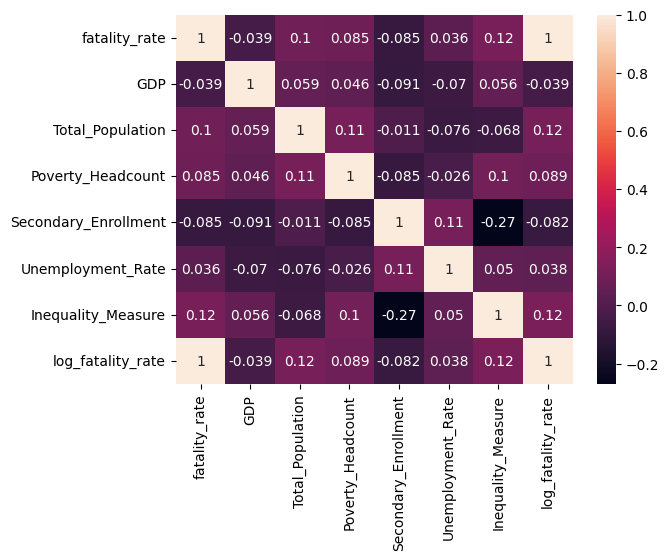

In [16]:
import seaborn as sns
sns.heatmap(df_model[cols + ['log_fatality_rate']].corr(), annot=True)

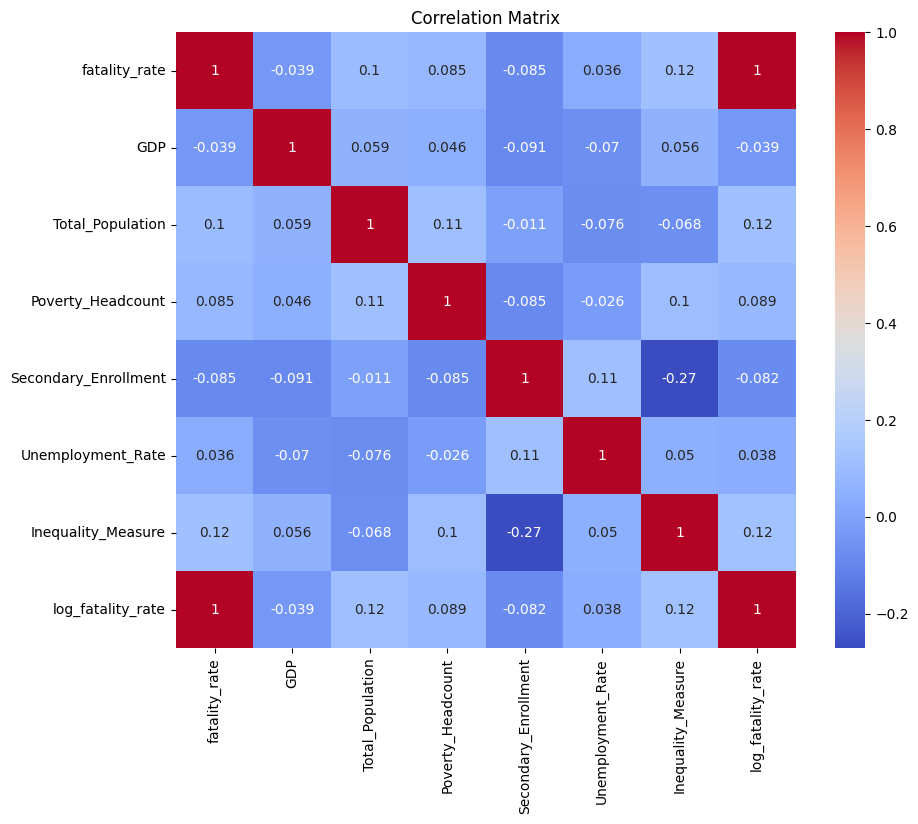

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
sns.heatmap(df_model[cols + ['log_fatality_rate']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [18]:
# Drop rows where fatality_rate is zero
df_model = df_model[df_model['fatality_rate'] > 0]
import pandas as pd

summary = pd.DataFrame({
    'NaN_Count': df_model.isna().sum(),
    'Zero_Count': (df_model == 0).sum(),
    'Total_Values': df_model.shape[0]
})

summary['NaN_%'] = (summary['NaN_Count'] / summary['Total_Values']) * 100
summary['Zero_%'] = (summary['Zero_Count'] / summary['Total_Values']) * 100

print(summary)

                      NaN_Count  Zero_Count  Total_Values  NaN_%      Zero_%
fatality_rate                 0           0          2749    0.0    0.000000
GDP                           0           3          2749    0.0    0.109131
Total_Population              0           0          2749    0.0    0.000000
Poverty_Headcount             0          27          2749    0.0    0.982175
Secondary_Enrollment          0           0          2749    0.0    0.000000
Unemployment_Rate             0           0          2749    0.0    0.000000
Inequality_Measure            0           0          2749    0.0    0.000000
log_fatality_rate             0           0          2749    0.0    0.000000
log_GDP                       0           3          2749    0.0    0.109131
log_population                0           0          2749    0.0    0.000000
is_zero                       0        2749          2749    0.0  100.000000


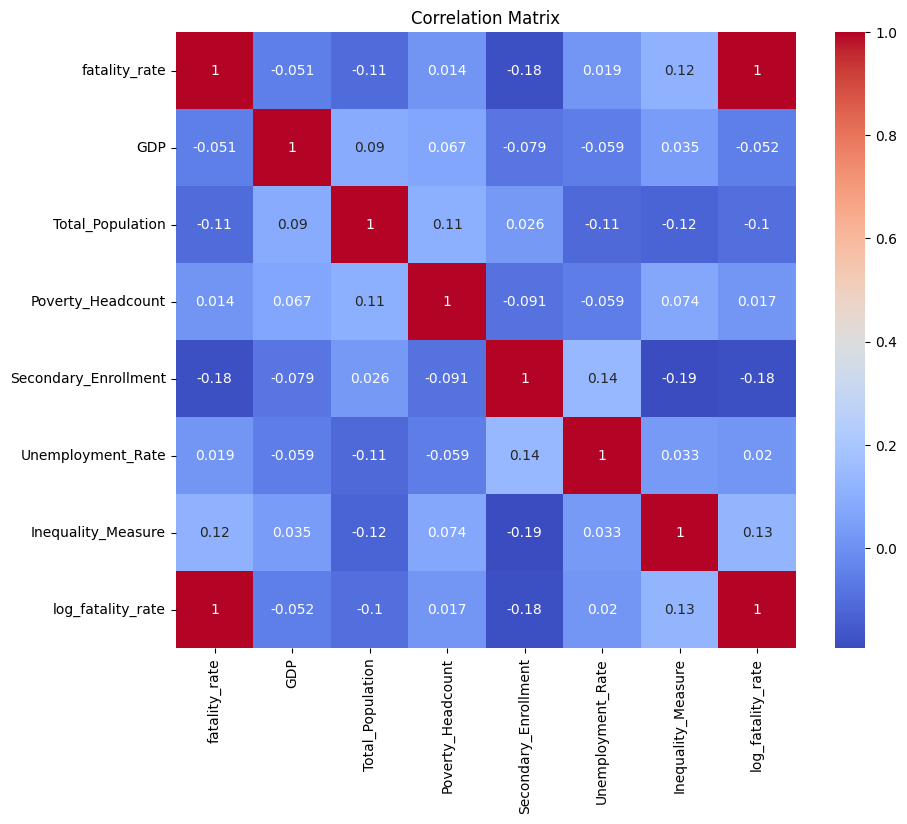

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
sns.heatmap(df_model[cols + ['log_fatality_rate']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_6716\434520809.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_plot.groupby('severity_group')[vars_to_plot].mean()


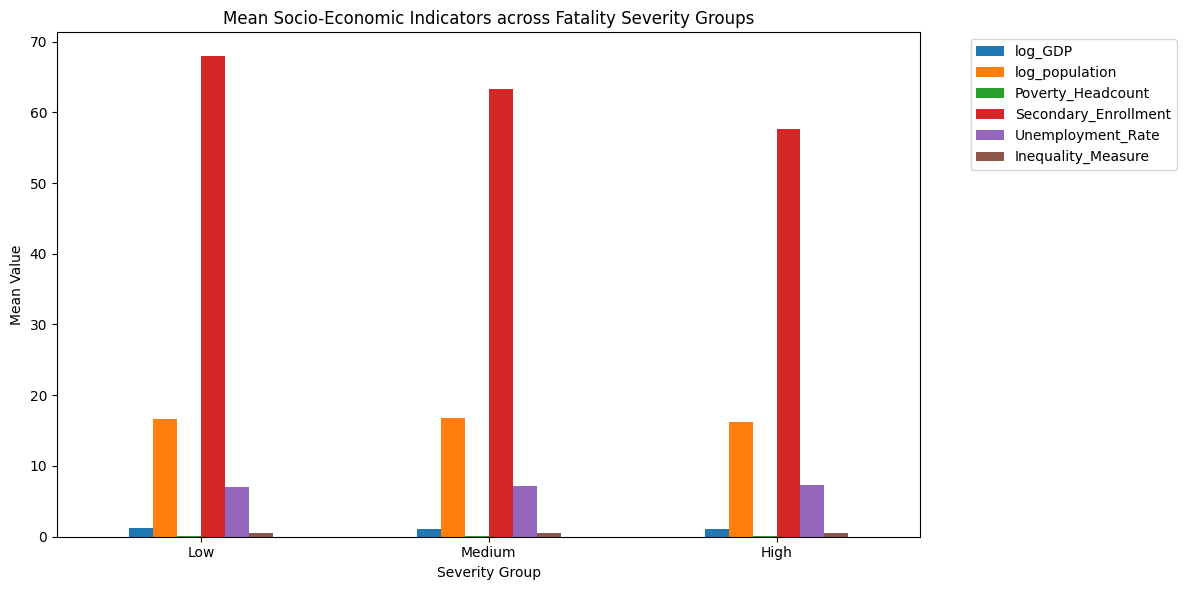

In [25]:
import matplotlib.pyplot as plt

# =========================
# 1️⃣ (Optional) Remove zero fatality rows
# =========================
df_plot = df_model[df_model['fatality_rate'] > 0].copy()

# =========================
# 2️⃣ Variables to Use
# =========================
vars_to_plot = [
    'log_GDP',
    'log_population',
    'Poverty_Headcount',
    'Secondary_Enrollment',
    'Unemployment_Rate',
    'Inequality_Measure'
]

# =========================
# 3️⃣ Create Severity Groups
# =========================
df_plot['severity_group'] = pd.qcut(
    df_plot['log_fatality_rate'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# =========================
# 4️⃣ Compute Means
# =========================
means = df_plot.groupby('severity_group')[vars_to_plot].mean()

# =========================
# 5️⃣ Plot
# =========================
means.plot(kind='bar', figsize=(12, 6))

plt.title("Mean Socio-Economic Indicators across Fatality Severity Groups")
plt.ylabel("Mean Value")
plt.xlabel("Severity Group")

plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [26]:
import pandas as pd
from scipy import stats
from scipy.stats import levene, f_oneway, kruskal

# =========================
# 1️⃣ Prepare Data (drop zeros)
# =========================
df_plot = df_model[df_model['fatality_rate'] > 0].copy()

# =========================
# 2️⃣ Variables (your dataset)
# =========================
vars_to_test = [
    'log_GDP',
    'log_population',
    'Poverty_Headcount',
    'Secondary_Enrollment',
    'Unemployment_Rate',
    'Inequality_Measure'
]

# =========================
# 3️⃣ Create Severity Groups
# =========================
df_plot['severity_group'] = pd.qcut(
    df_plot['log_fatality_rate'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# =========================
# 4️⃣ Function to format p-values
# =========================
def format_p(p):
    if p < 0.001:
        return f"< 0.001 ({p:.2e})"
    else:
        return f"{p:.4f}"

# =========================
# 5️⃣ Loop through variables
# =========================
for var in vars_to_test:
    print("\n" + "="*65)
    print(f"🔹 Analysis for: {var.upper()}")
    print("="*65)
    
    group_data = []
    normal_flag = True
    
    # ---------------------------
    # 1. Shapiro Test
    # ---------------------------
    print("\nNormality Test (Shapiro-Wilk):")
    
    for name, group in df_plot.groupby('severity_group'):
        data = group[var].dropna()
        
        # Shapiro fails if too many samples → cap size
        if len(data) > 5000:
            data = data.sample(5000, random_state=42)
        
        stat, p = stats.shapiro(data)
        
        if p < 0.05:
            normal_flag = False
        
        print(f"{name:<10} → p = {format_p(p)}")
        group_data.append(data)
    
    # ---------------------------
    # 2. Levene Test
    # ---------------------------
    lev_stat, lev_p = levene(*group_data)
    print(f"\nLevene Test (Equal Variance): p = {format_p(lev_p)}")
    
    # ---------------------------
    # 3. ANOVA
    # ---------------------------
    f_stat, f_p = f_oneway(*group_data)
    print(f"ANOVA Result: p = {format_p(f_p)}")
    
    # ---------------------------
    # 4. Kruskal-Wallis
    # ---------------------------
    k_stat, k_p = kruskal(*group_data)
    print(f"Kruskal-Wallis Result: p = {format_p(k_p)}")
    
    # ---------------------------
    # 5. Final Decision
    # ---------------------------
    print("\nFinal Decision:")
    
    if normal_flag and lev_p > 0.05:
        print("→ Use ANOVA (assumptions satisfied)")
    else:
        print("→ Use Kruskal-Wallis (non-parametric preferred)")
    
    # ---------------------------
    # 6. Significance Conclusion
    # ---------------------------
    if k_p < 0.05:
        print("→ Significant differences exist across severity groups")
    else:
        print("→ No significant differences across groups")


🔹 Analysis for: LOG_GDP

Normality Test (Shapiro-Wilk):


C:\Users\DELL\AppData\Local\Temp\ipykernel_6716\788923264.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in df_plot.groupby('severity_group'):


Low        → p = < 0.001 (5.99e-33)
Medium     → p = < 0.001 (2.65e-32)
High       → p = < 0.001 (8.69e-31)

Levene Test (Equal Variance): p = < 0.001 (3.13e-04)
ANOVA Result: p = 0.0015
Kruskal-Wallis Result: p = 0.1276

Final Decision:
→ Use Kruskal-Wallis (non-parametric preferred)
→ No significant differences across groups

🔹 Analysis for: LOG_POPULATION

Normality Test (Shapiro-Wilk):
Low        → p = < 0.001 (4.87e-16)
Medium     → p = < 0.001 (3.25e-17)
High       → p = < 0.001 (5.55e-13)

Levene Test (Equal Variance): p = < 0.001 (9.49e-09)
ANOVA Result: p = < 0.001 (8.42e-21)
Kruskal-Wallis Result: p = < 0.001 (9.53e-16)

Final Decision:
→ Use Kruskal-Wallis (non-parametric preferred)
→ Significant differences exist across severity groups

🔹 Analysis for: POVERTY_HEADCOUNT

Normality Test (Shapiro-Wilk):
Low        → p = < 0.001 (1.16e-49)
Medium     → p = < 0.001 (9.94e-48)
High       → p = < 0.001 (3.95e-50)

Levene Test (Equal Variance): p = 0.8451
ANOVA Result: p = 0.7326


In [31]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# =========================
# 1️⃣ Use only non-zero data
# =========================
df_ols = df_model[df_model['fatality_rate'] > 0].copy()

# =========================
# 2️⃣ Define X and y
# =========================
features = [
    'GDP',
    'Total_Population',
    'Poverty_Headcount',
    'Secondary_Enrollment',
    'Unemployment_Rate',
    'Inequality_Measure'
]

X = df_ols[features]
y = df_ols['log_fatality_rate']

# =========================
# 3️⃣ Standardize (Z-score)
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (important for names)
X_scaled = pd.DataFrame(X_scaled, columns=features, index=X.index)

# =========================
# 4️⃣ Add constant
# =========================
X_scaled = sm.add_constant(X_scaled)

# =========================
# 5️⃣ OLS with Robust SE
# =========================
model_ols = sm.OLS(y, X_scaled).fit(cov_type='HC3')

print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:      log_fatality_rate   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     30.98
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           3.47e-36
Time:                        09:16:21   Log-Likelihood:                 619.80
No. Observations:                2749   AIC:                            -1226.
Df Residuals:                    2742   BIC:                            -1184.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.3971 